# Assignment 1

## Imports

In [ ]:
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
import torch 
import matplotlib.pyplot as plt
import pandas as pd
import os

2.10.0
2.21.0


## 1. Load and visualise dataset

In [3]:
# Load dataset and label names from A_TXT and N_TXT folders
raw_data = []
labels = []
subjects = []

for folder in ['Data/A_TXT', 'Data/N_TXT']:
    for filename in os.listdir(folder):
        file_path = os.path.join(folder, filename)
        df = pd.read_csv(file_path, skiprows=7, sep='\t', usecols=range(5), names=['EMG1', 'EMG2', 'EMG3', 'EMG4', 'FX'])
        # Remove NaN values
        df.dropna(inplace=True)
        raw_data.append(df)

        # Extract label from "mar, pie, sen" in filename
        if 'mar' in filename:
            labels.append('walking')
        elif 'pie' in filename:
            labels.append('standing')
        elif 'sen' in filename:
            labels.append('sitting')
            
        # Extract subject from filename (e.g. 1A from 1Amar.txt)
        subject = filename.split('.')[0][:-3]  # Remove last 3 chars (mar, pie, sen)
        subjects.append(subject)
        # print(f"Loaded {filename}: {df.shape} - Label: {labels[-1]} ")
        

print(f"\nTotal files loaded: {len(raw_data)}")
print(f"Labels -  walking: {labels.count('walking')}, standing: {labels.count('standing')}, sitting: {labels.count('sitting')}")
print(f"\nFirst few rows of raw_data[0]:\n{raw_data[0].head()}")
print(f"\nSubjects: {list(set(subjects))}\nCount: {len(set(subjects))}")



Total files loaded: 66
Labels -  walking: 22, standing: 22, sitting: 22

First few rows of raw_data[0]:
     EMG1    EMG2    EMG3    EMG4    FX
0 -0.0008 -0.0008  0.0000 -0.0030 -74.8
1  0.0037 -0.0015 -0.0023 -0.0046 -74.8
2  0.0030 -0.0008 -0.0015 -0.0023 -74.6
3  0.0037 -0.0030  0.0000 -0.0030 -74.7
4  0.0030  0.0000 -0.0015 -0.0015 -74.7

Subjects: ['3A', '7N', '5A', '9N', '11A', '6N', '11N', '5N', '1N', '6A', '1A', '4N', '9A', '4A', '10A', '8N', '2N', '7A', '3N', '8A', '10N', '2A']
Count: 22


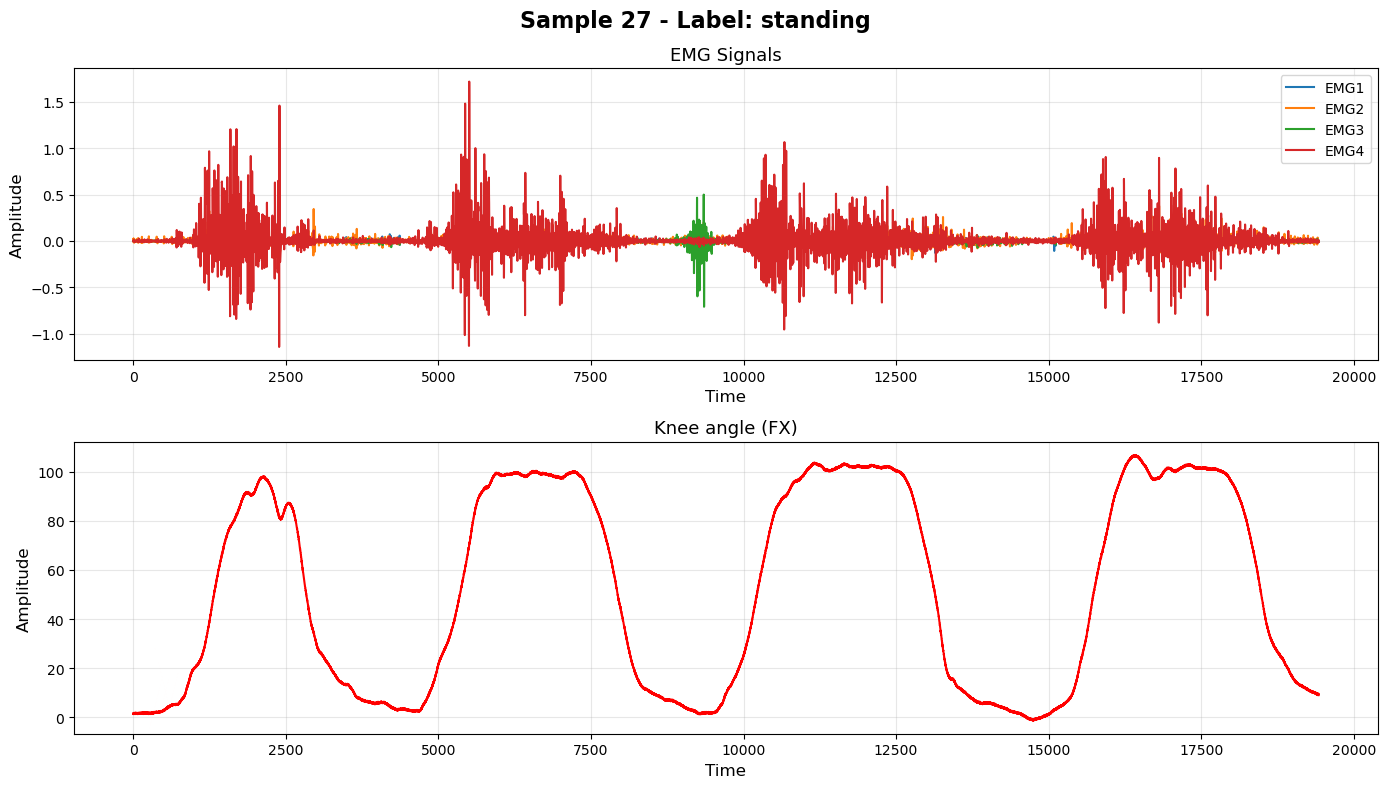

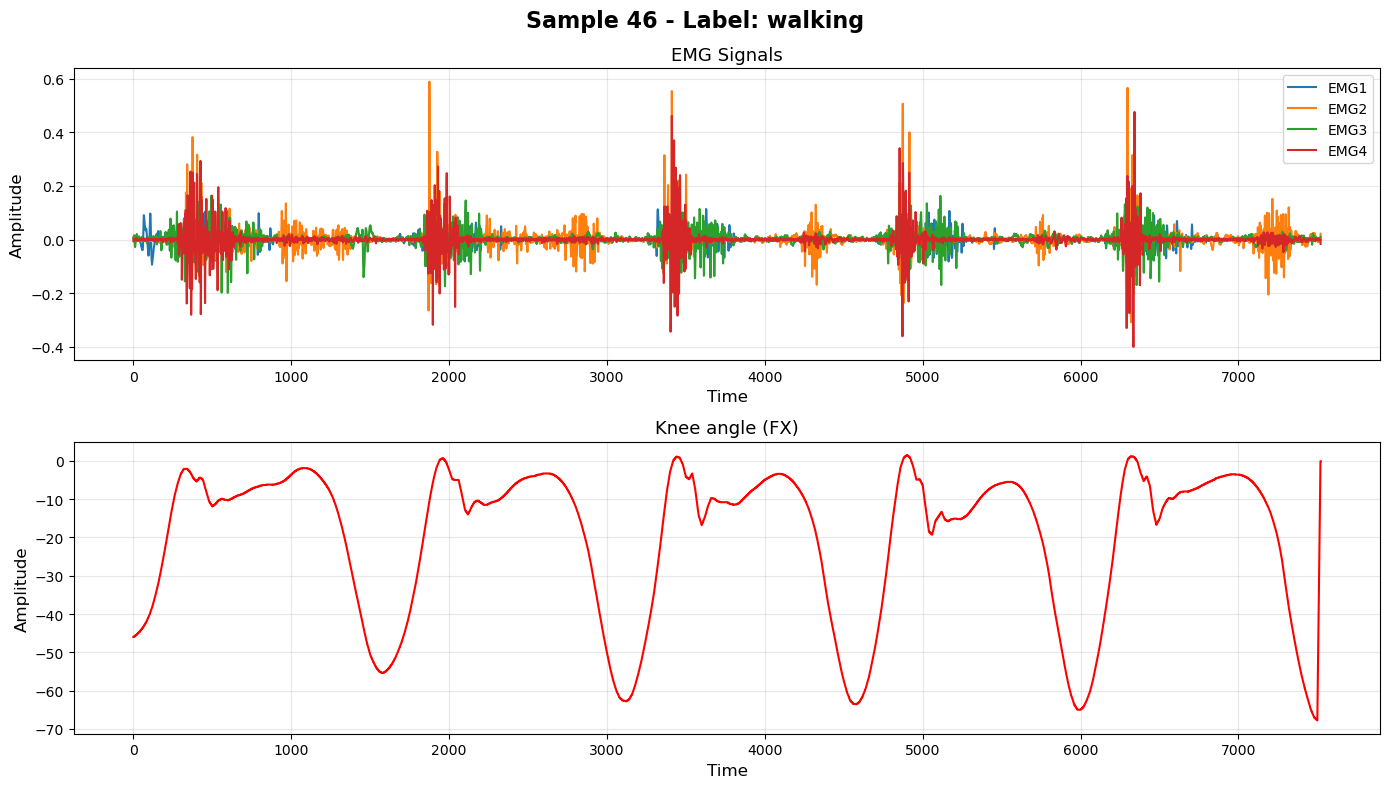

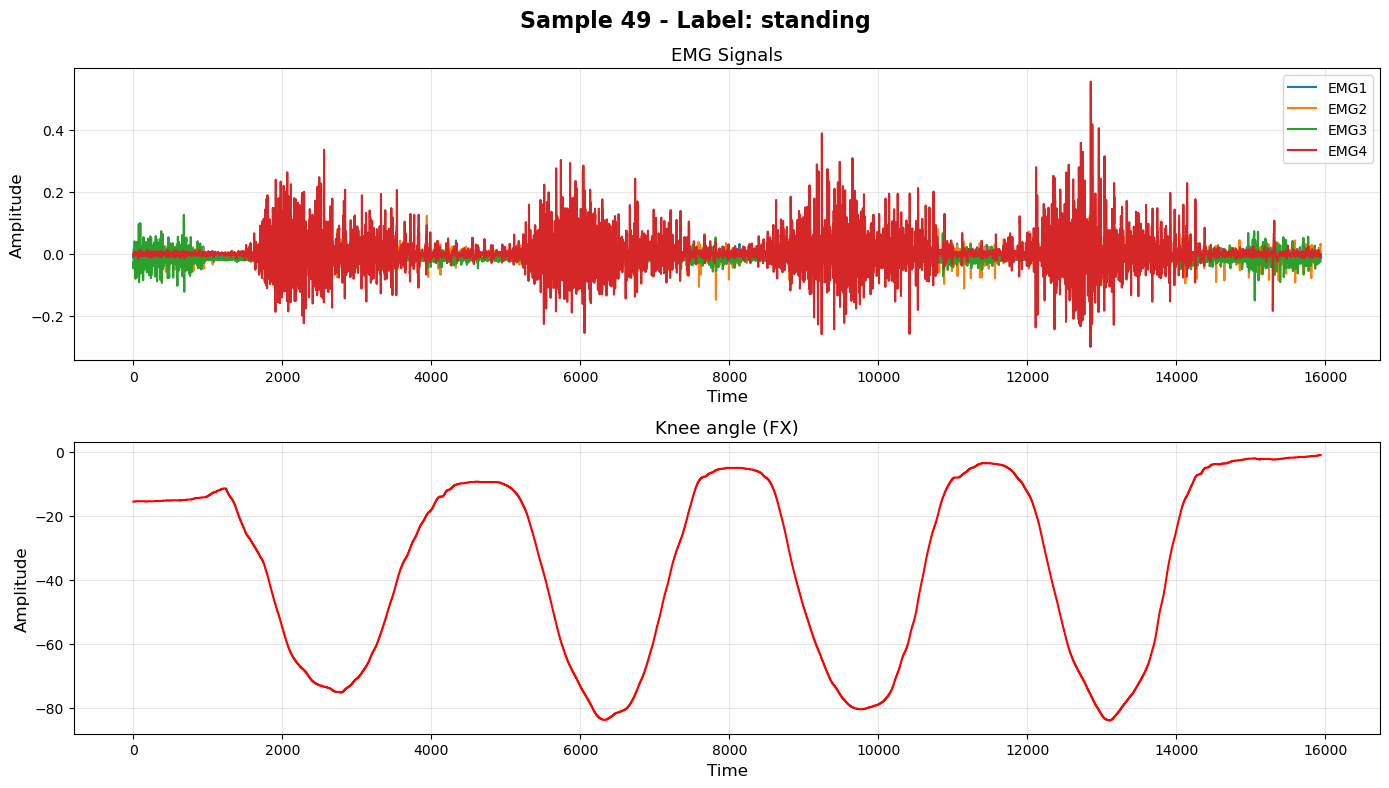

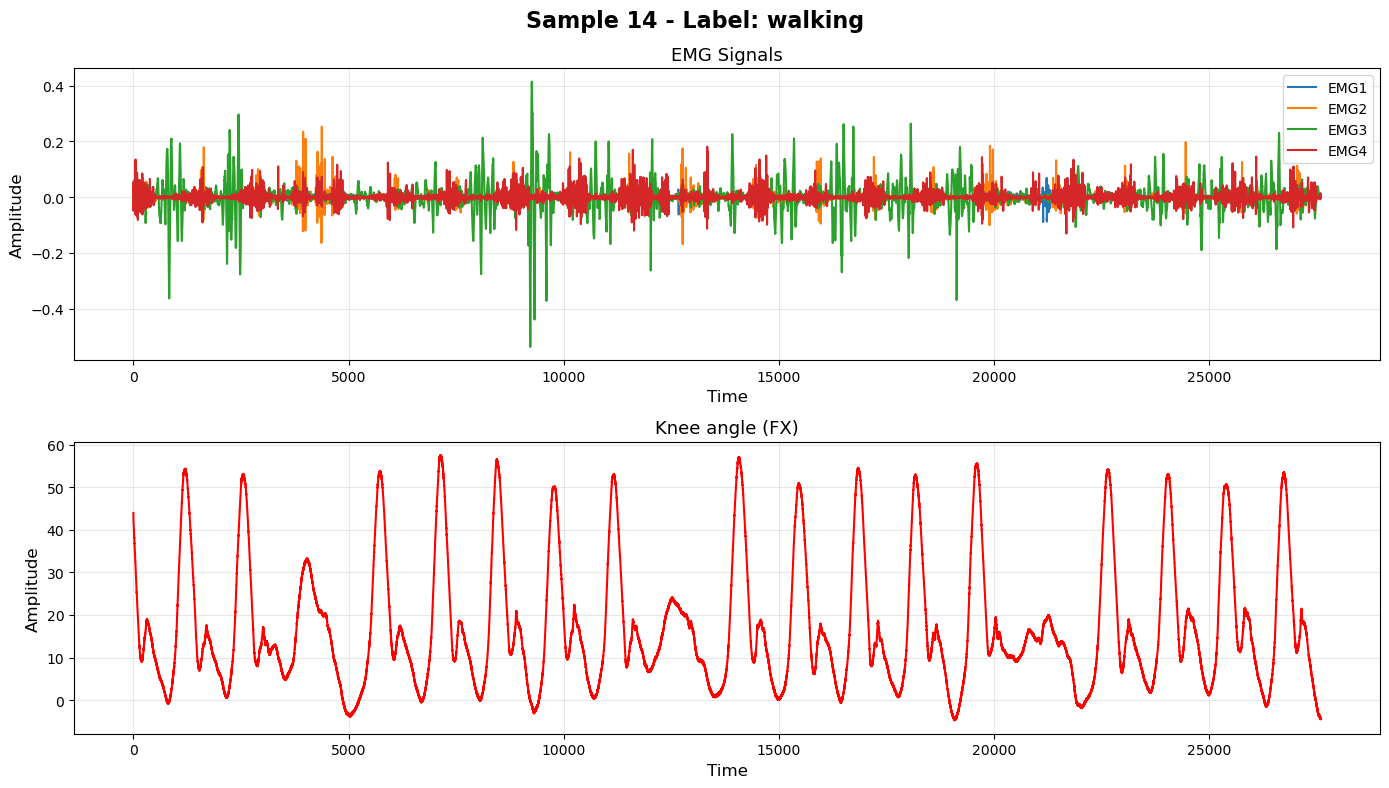

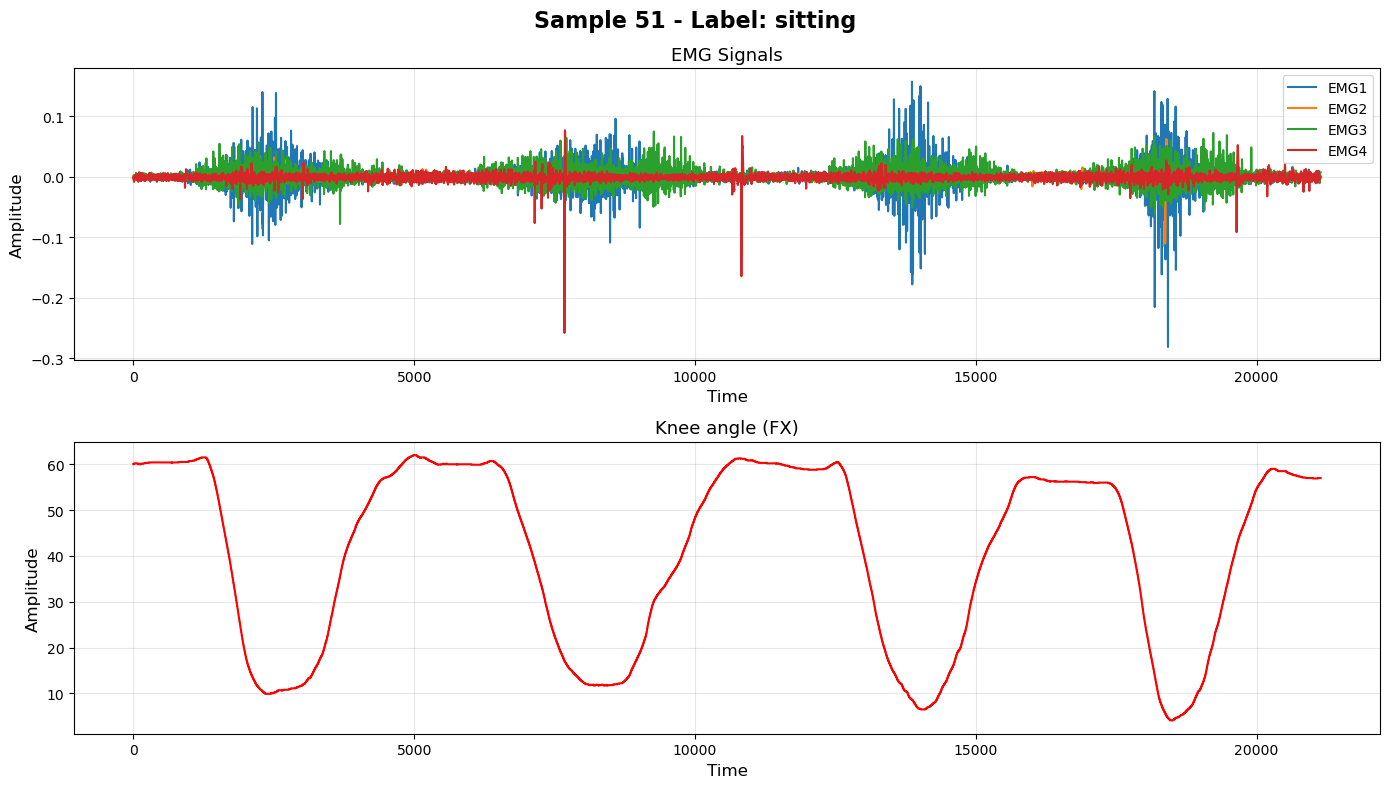

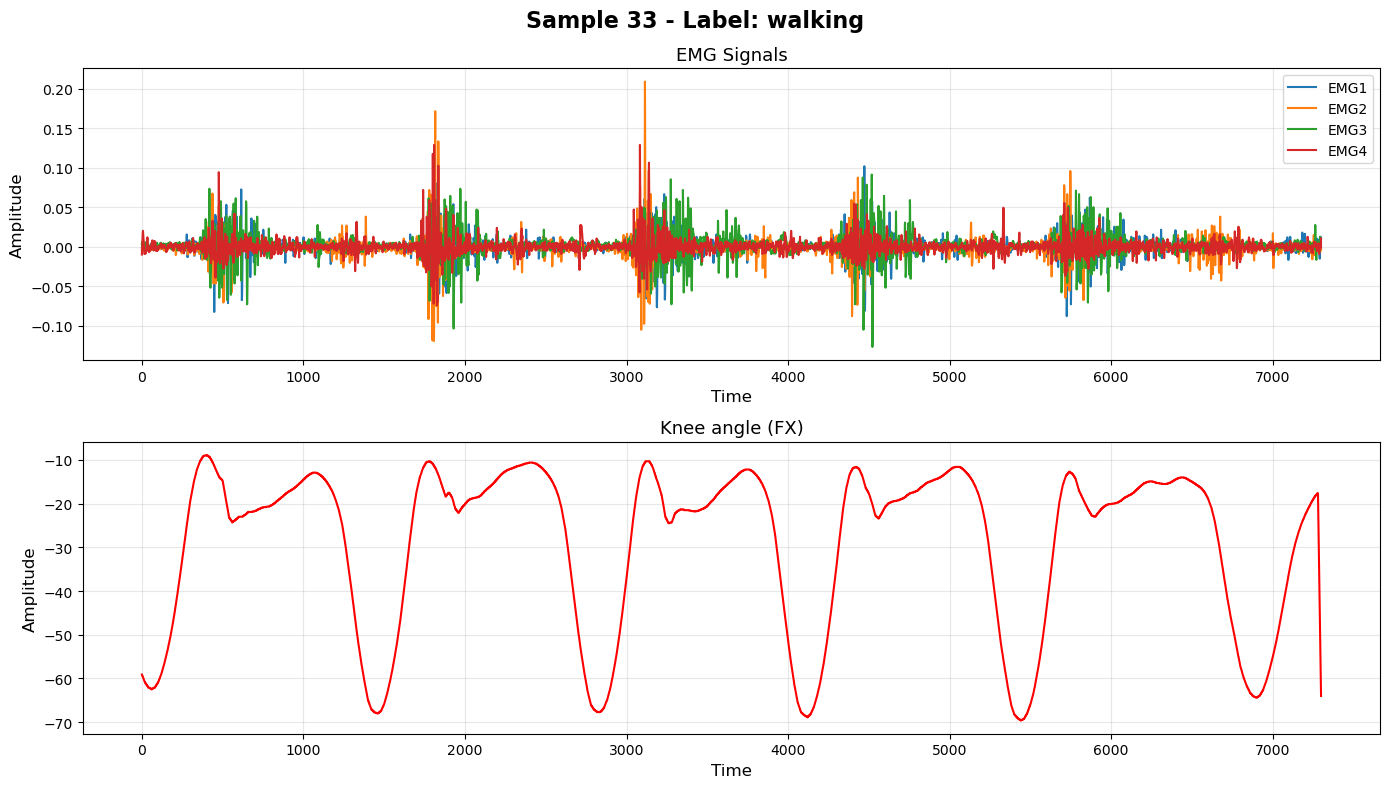

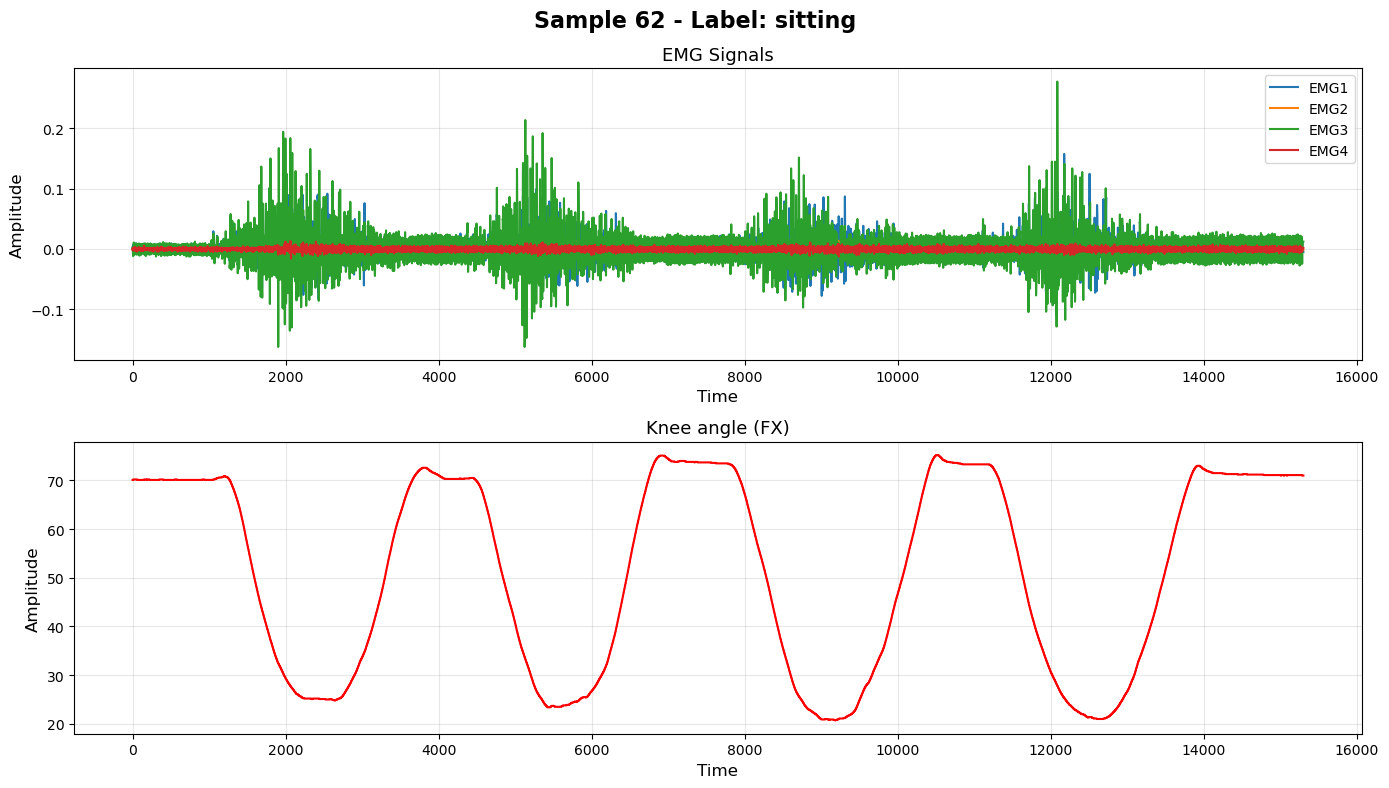

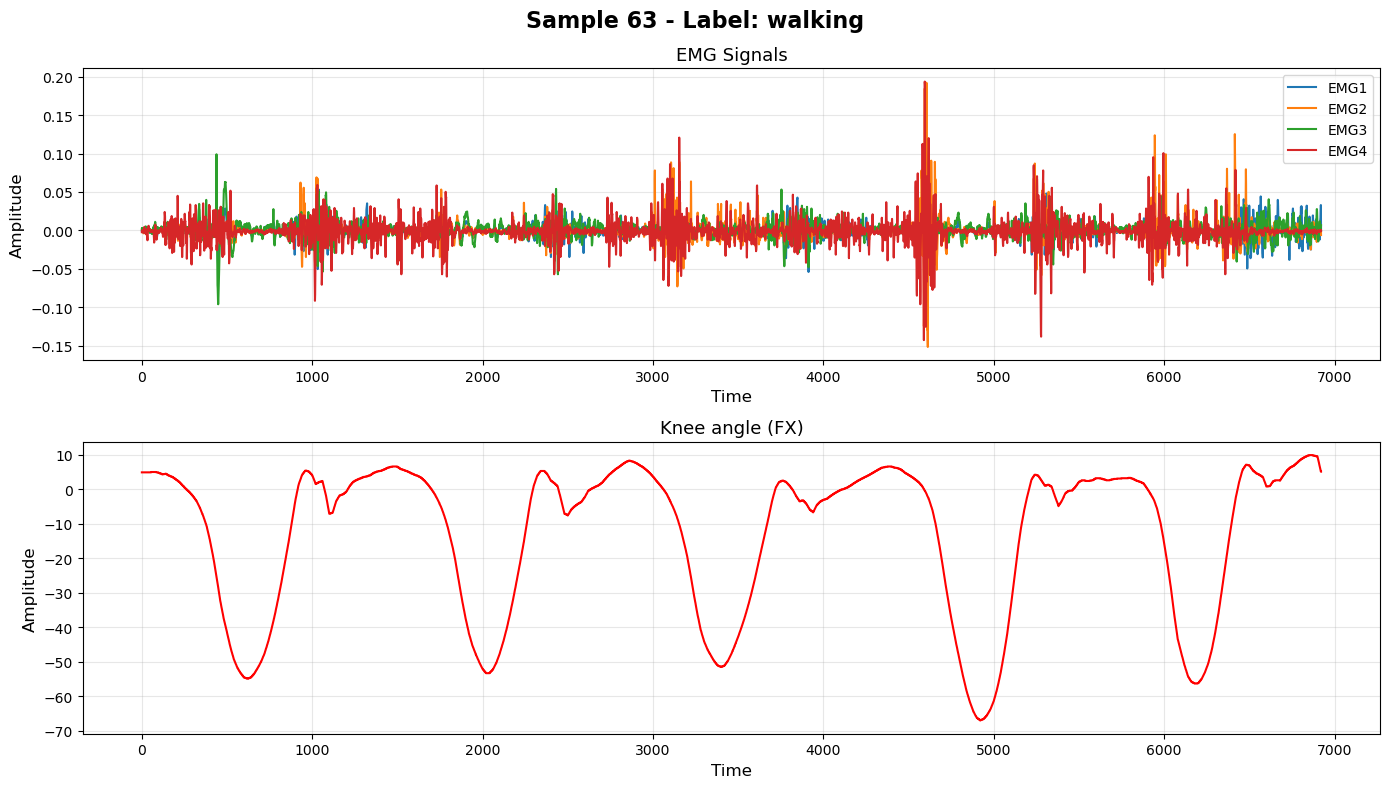

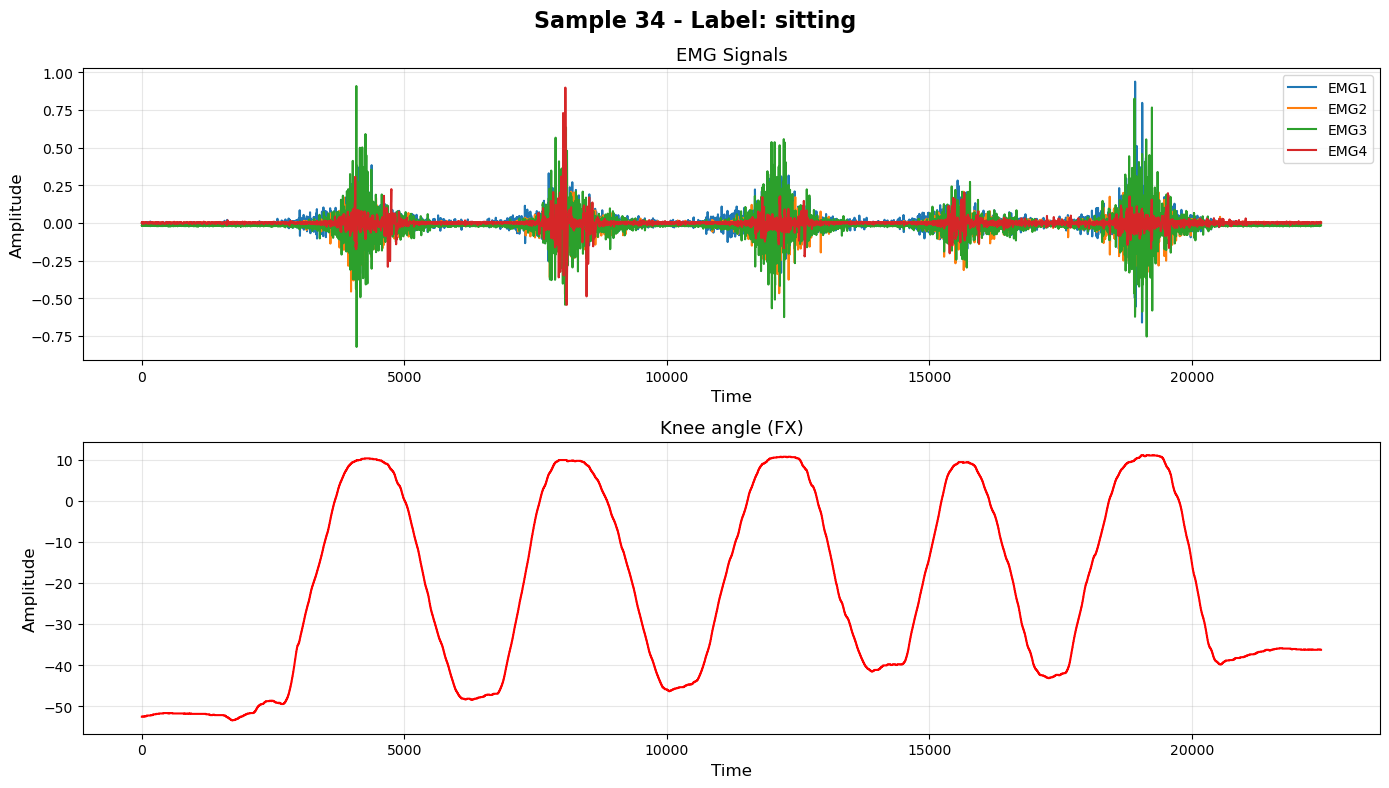

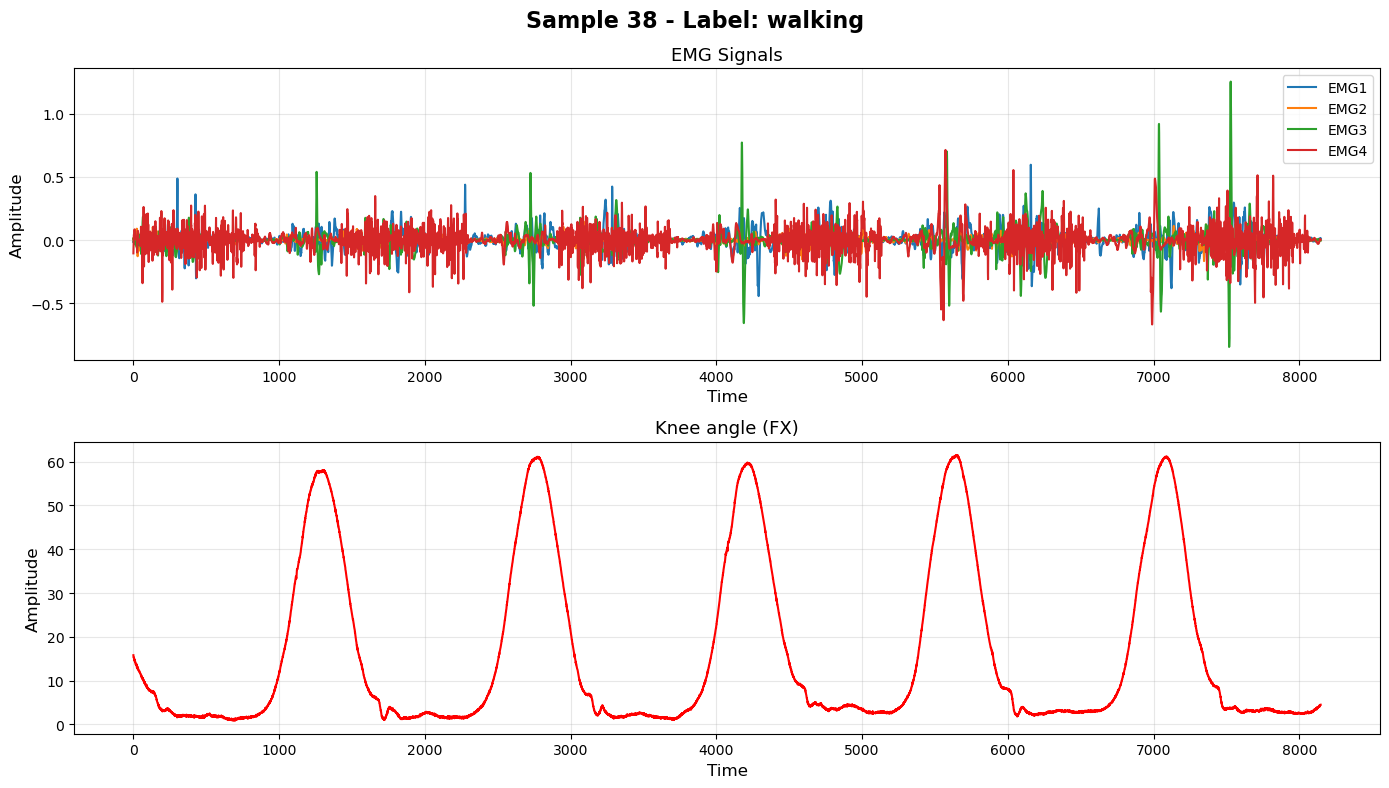

In [4]:
def plot_random_samples(data, labels, num_samples=10):
    # Pick 10 random samples from the dataset and plot them on time series plots with labels as titles
    random_indices = np.random.choice(len(data), num_samples, replace=False)
    for idx in random_indices:
        df = data[idx]
        label = labels[idx]
        fig, axes = plt.subplots(2, 1, figsize=(14, 8))
        fig.suptitle(f"Sample {idx} - Label: {label}", fontsize=16, fontweight='bold')
        
        axes[0].plot(df[['EMG1', 'EMG2', 'EMG3', 'EMG4']])
        axes[0].set_xlabel('Time', fontsize=12)
        axes[0].set_ylabel('Amplitude', fontsize=12)
        axes[0].set_title('EMG Signals', fontsize=13)
        axes[0].legend(['EMG1', 'EMG2', 'EMG3', 'EMG4'], loc='best')
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(df['FX'], color='red', linewidth=1.5)
        axes[1].set_xlabel('Time', fontsize=12)
        axes[1].set_ylabel('Amplitude', fontsize=12)
        axes[1].set_title('Knee angle (FX)', fontsize=13)
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

plot_random_samples(raw_data, labels, num_samples=10)


In [5]:
# Stats about signals
min_max_values = {}
print("\nTotal signal Statistics:")
for i in range(1, 5):
    emg_values = np.concatenate([df[f'EMG{i}'].values for df in raw_data])
    print(f"EMG{i} - Mean: {emg_values.mean():.4f}, Std: {emg_values.std():.4f}, Min: {emg_values.min():.4f}, Max: {emg_values.max():.4f}")
    min_max_values[f'EMG{i}'] = (emg_values.min(), emg_values.max())
    
fx_values = np.concatenate([df['FX'].values for df in raw_data])
print(f"FX - Mean: {fx_values.mean():.4f}, Std: {fx_values.std():.4f}, Min: {fx_values.min():.4f}, Max: {fx_values.max():.4f}")
min_max_values['FX'] = (fx_values.min(), fx_values.max())

print('====================================\n')
print("Class-wise signal Statistics:")
for label in set(labels):
    print(f"\nLabel: {label}")
    for i in range(1, 5):
        emg_values = np.concatenate([df[f'EMG{i}'].values for df, lbl in zip(raw_data, labels) if lbl == label])
        print(f"EMG{i} - Mean: {emg_values.mean():.4f}, Std: {emg_values.std():.4f}, Min: {emg_values.min():.4f}, Max: {emg_values.max():.4f}")
    fx_values = np.concatenate([df['FX'].values for df, lbl in zip(raw_data, labels) if lbl == label])
    print(f"FX - Mean: {fx_values.mean():.4f}, Std: {fx_values.std():.4f}, Min: {fx_values.min():.4f}, Max: {fx_values.max():.4f}")
    



Total signal Statistics:
EMG1 - Mean: -0.0004, Std: 0.0526, Min: -1.5578, Max: 1.5457
EMG2 - Mean: -0.0004, Std: 0.0342, Min: -0.8475, Max: 0.8175
EMG3 - Mean: 0.0003, Std: 0.0652, Min: -1.8315, Max: 1.9710
EMG4 - Mean: -0.0001, Std: 0.0460, Min: -1.3193, Max: 1.7190
FX - Mean: 19.5157, Std: 45.4155, Min: -130.0000, Max: 121.3000

Class-wise signal Statistics:

Label: standing
EMG1 - Mean: -0.0004, Std: 0.0178, Min: -0.6008, Max: 0.6555
EMG2 - Mean: -0.0004, Std: 0.0496, Min: -0.7838, Max: 0.8175
EMG3 - Mean: 0.0001, Std: 0.0132, Min: -0.7095, Max: 0.5002
EMG4 - Mean: -0.0001, Std: 0.0599, Min: -1.1430, Max: 1.7190
FX - Mean: 28.2634, Std: 58.0491, Min: -130.0000, Max: 121.3000

Label: sitting
EMG1 - Mean: -0.0004, Std: 0.0425, Min: -0.6608, Max: 0.9375
EMG2 - Mean: -0.0004, Std: 0.0239, Min: -0.8475, Max: 0.7395
EMG3 - Mean: 0.0002, Std: 0.0557, Min: -1.2930, Max: 0.9780
EMG4 - Mean: -0.0000, Std: 0.0323, Min: -1.3193, Max: 1.3462
FX - Mean: 19.4700, Std: 46.1211, Min: -95.3000, Max:

## 2. Preprocessing data
- Using min/max normalisation using global min/max values. 
- Windowing into fixed (250ms) segments with stride (x ms).

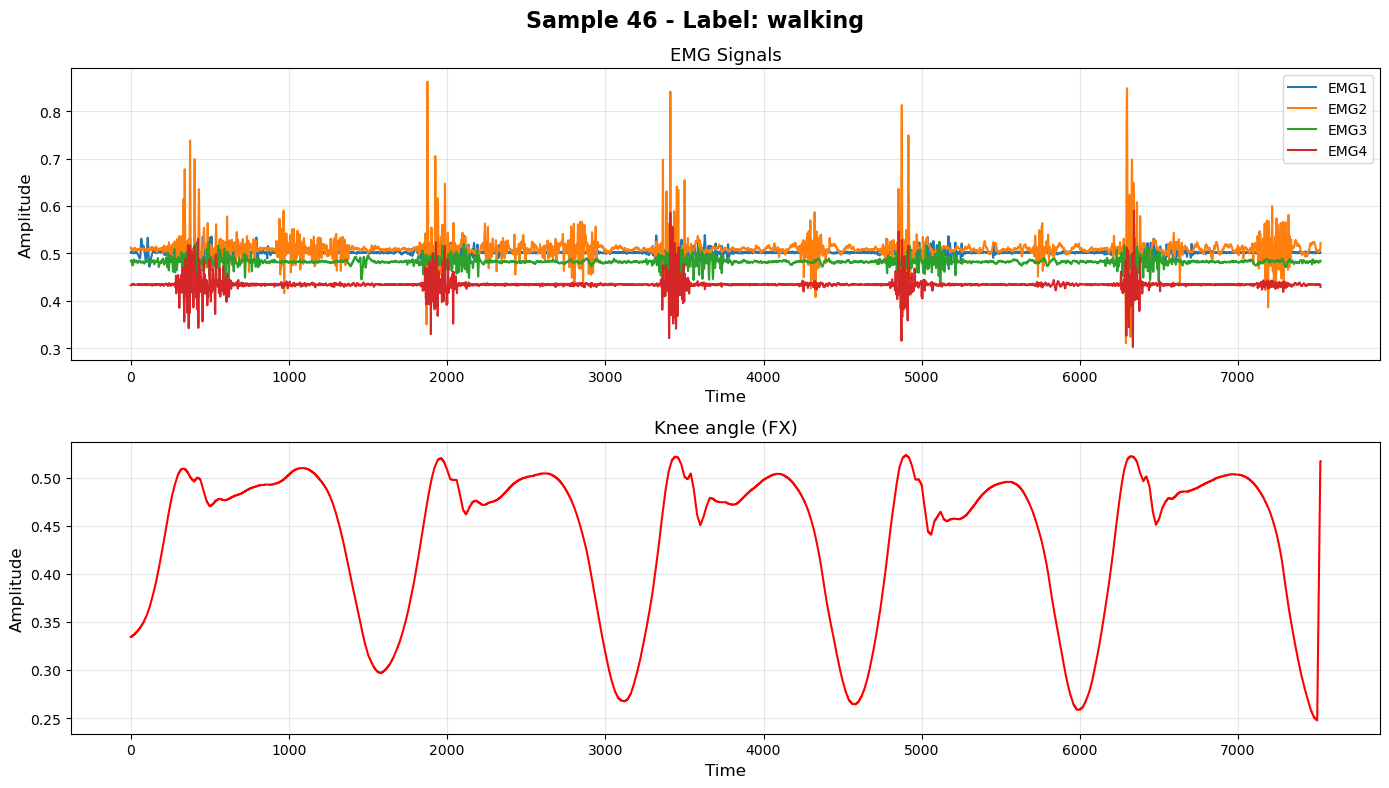

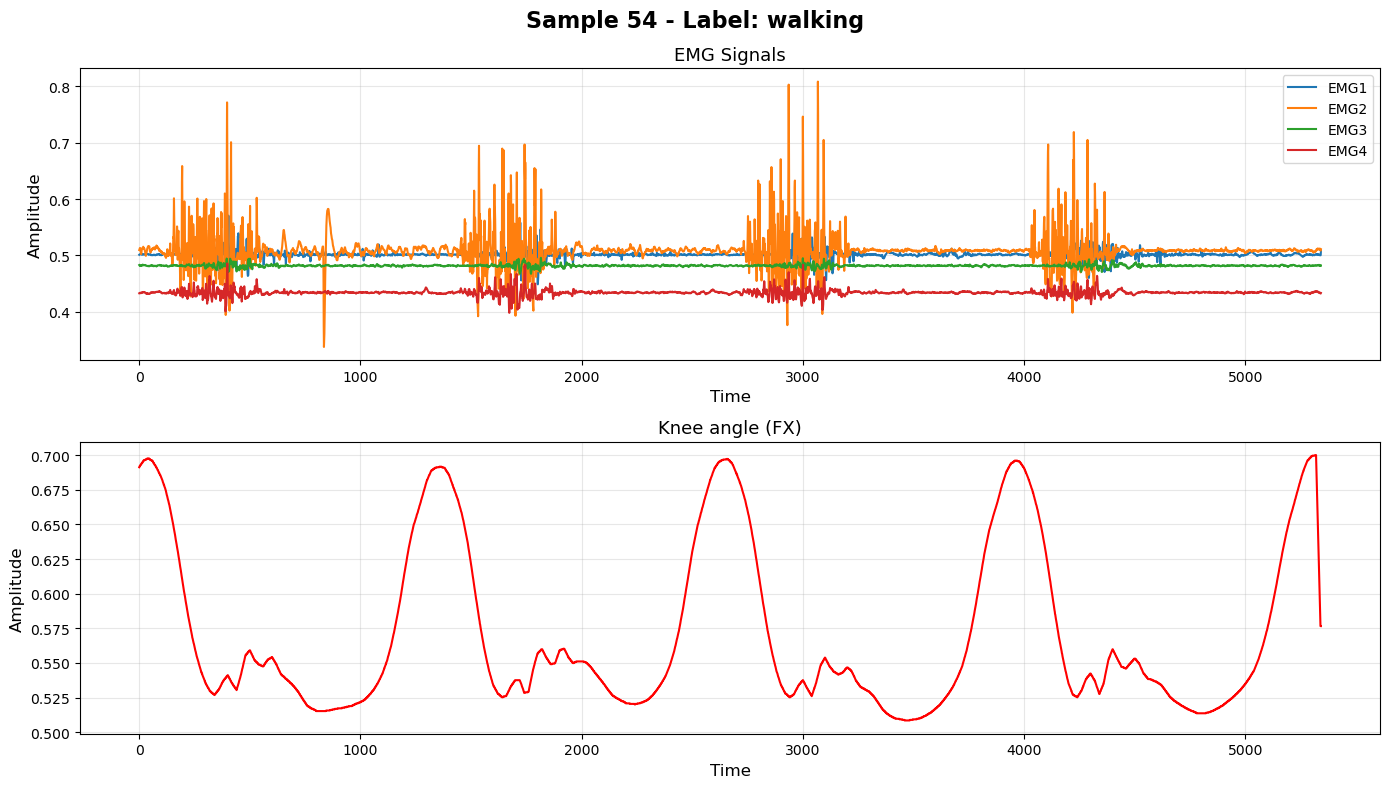

In [6]:
# Min-max normalization of the dataset
normalized_data = []
for df in raw_data:
    df_normalized = df.copy()
    for col in ['EMG1', 'EMG2', 'EMG3', 'EMG4', 'FX']:
        min_val, max_val = min_max_values[col]
        df_normalized[col] = (df[col] - min_val) / (max_val - min_val)
    normalized_data.append(df_normalized)

plot_random_samples(normalized_data, labels, num_samples=2)

In [7]:
# Windowing into 250ms segments = 250 samples at 1000Hz
# Stride of 125 samples (50% overlap)
# Drop last segment if it is less than 250 samples 
window_size = 250
stride = 125

data = [] # list containing (label, dataframe) with each dataframe containing 250 samples
subjects_windows = []
for i, df in enumerate(normalized_data):
    window_subject = subjects[i]
    window_label = labels[i]
    num_samples = len(df)
    for start in range(0, num_samples - window_size + 1, stride):
        end = start + window_size
        data.append((window_subject,window_label, df[start:end]))
        subjects_windows.append(window_subject)
        
print(f"\nTotal segments created: {len(data)}")
print(f"Class distribution in segments - walking: {sum(1 for _,lbl, _ in data if lbl == 'walking')}, standing: {sum(1 for _,lbl, _ in data if lbl == 'standing')}, sitting: {sum(1 for _,lbl, _ in data if lbl == 'sitting')}")

for s in subjects:
    print(f"Subject {s} - Segments: {sum(1 for sub in subjects_windows if sub == s)}")
    
    


Total segments created: 10502
Class distribution in segments - walking: 3216, standing: 3337, sitting: 3949
Subject 8A - Segments: 329
Subject 6A - Segments: 1311
Subject 1A - Segments: 325
Subject 9A - Segments: 576
Subject 8A - Segments: 329
Subject 9A - Segments: 576
Subject 7A - Segments: 359
Subject 1A - Segments: 325
Subject 11A - Segments: 574
Subject 2A - Segments: 296
Subject 3A - Segments: 833
Subject 5A - Segments: 724
Subject 10A - Segments: 470
Subject 2A - Segments: 296
Subject 11A - Segments: 574
Subject 4A - Segments: 957
Subject 10A - Segments: 470
Subject 3A - Segments: 833
Subject 8A - Segments: 329
Subject 6A - Segments: 1311
Subject 7A - Segments: 359
Subject 1A - Segments: 325
Subject 6A - Segments: 1311
Subject 9A - Segments: 576
Subject 7A - Segments: 359
Subject 2A - Segments: 296
Subject 4A - Segments: 957
Subject 11A - Segments: 574
Subject 5A - Segments: 724
Subject 4A - Segments: 957
Subject 3A - Segments: 833
Subject 10A - Segments: 470
Subject 5A - Segme

## 3. Train and test a classification model

### Split into training/validation/test sets

In [8]:
# Step 1: Split into train+val (80%) and test (20%) by subject
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss.split(data, groups=subjects_windows))

# Step 2: Split train+val into train (80%) and val (25%) by subject - this will give us 60% train, 20% val, 20% test by subject
train_idx, val_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42).split(
    [data[i] for i in train_val_idx], groups=[subjects_windows[i] for i in train_val_idx]))

# Step 3: Adjust indices back to original data indices
train_idx = [train_val_idx[i] for i in train_idx]
val_idx = [train_val_idx[i] for i in val_idx]

# Step 4: Create the actual split lists
train_data = [data[i] for i in train_idx]
val_data = [data[i] for i in val_idx]
test_data = [data[i] for i in test_idx]

# Step 5: Verify
print(f"Train windows: {len(train_data)}, Validation windows: {len(val_data)}, Test windows: {len(test_data)}")
print(f"Train subjects: {set(d[0] for d in train_data)}")
print(f"Test subjects: {set(d[0] for d in test_data)}")  
print(f"Val subjects: {set(d[0] for d in val_data)}")

Train windows: 5942, Validation windows: 2066, Test windows: 2494
Train subjects: {'8N', '4N', '7N', '4A', '1N', '5A', '8A', '3N', '6A', '1A', '2A', '9N'}
Test subjects: {'5N', '3A', '10N', '10A', '6N'}
Val subjects: {'11N', '2N', '9A', '7A', '11A'}


#### Discussion about generalisation:
Subject wise splitting ensures that test is on unseen subject. This tests generalization, by seeing if the model can learn universal activity patterns that apply to any person, not just training subjects. If 1 subject would appear in both tests, the model might learn its characteristics (e.g. "subject 2N has high EMG values when standing", "subject 10A has low FX peaks"). The goal of this model is not just to work on 1 person, it is to be albe to use it on a new patient aswell, and therefore we need to test that ability. By splitting randomly (not by subject), the model might overfit to individuals, effectively cheating and making the overall accuracy higher than it actually is.


### CHATGPT Recommended Modeling Approach: 
**1D Convolutional Neural Network** (Recommended)

**Pros:**
- Efficiently extracts local temporal patterns from short 250-sample windows across 5 channels.
- Learns generalizable spatial-temporal signatures that transfer to new subjects.
- Faster training and inference than RNNs—good for real-time applications.
- Less prone to overfitting with moderate data amount.
- Multi-channel convolutions naturally capture EMG-FX interactions.

**Architecture sketch:** Conv1D (32 filters, k=5) → MaxPool → Conv1D (64 filters, k=3) → MaxPool → Flatten → Dense(128) → Dropout → Dense(3 softmax).

---

**Alternative Approaches - Why NOT to use them:**

**LSTM/GRU (Recurrent Networks)**
- *Cons:* Designed for very long sequences (1000s of steps); 250 samples is too short to benefit.
- Slower training and inference than CNNs; harder to tune (vanishing gradients, gate mechanisms).
- Risk of overfitting with your moderate dataset (~9 subjects per split).
- Unnecessary complexity for capturing local 50-200ms patterns in EMG.

**Temporal Convolutional Network (TCN)**
- *Cons:* Overkill for 250-sample windows; designed for 1000s+ timesteps with long-range dependencies.
- More complex architecture (dilated convolutions, skip connections) than needed.
- Requires careful hyperparameter tuning (dilation rates, filter sizes).
- Minimal performance gain over simpler 1D CNN for short windows.

**MLP on Extracted Window-Features**
- *Cons:* Requires manual feature engineering (RMS, mean frequency, spectral features, etc.)—tedious and domain-dependent.
- Ignores temporal dynamics within windows; loses information about EMG evolution over the 250ms.
- No automatic discovery of feature interactions—must engineer them manually.
- Less generalizable across different subjects' EMG characteristics.

### Train and test model (1D CNN)

# AI Usage Log



*   **GitHub Copilot** *Q:* How to open/extract RAR files on macOS? *A:* Use `brew install unrar` then `unrar x filename.rar` in terminal, or use GUI tools like The Unarchiver.

*   **GitHub Copilot** *Q:* Explain folder structure of EMG dataset. *A:* 4 folders: A_LOG/A_TXT (abnormal knee patients), N_LOG/N_TXT (normal knee patients). Use _TXT folders for analysis with pd.read_csv().

*   **GitHub Copilot** *Q:* Load .txt files as dataframes. *A:* Use pd.read_csv(filepath, sep='\s+', header=0) to handle space/tab-separated values with headers.

*   **GitHub Copilot** *Q:* Make plots about signals.  *A:* Use matplotlib to create plots.

*   **GitHub Copilot** *Q:* Global vs individual min/max normalization for EMG datasets? *A:* For ML tasks, use global min/max (all datasets combined) for consistent scaling. Individual min/max is better for analyzing within-sample variations. Alternative: use StandardScaler (Z-score) which is more robust to outliers.

*   **GitHub Copilot** *Q:* What does "Windowing into fixed-length segments (250 ms recommended) with stride, with a label per window" mean? *A:* Windowing breaks continuous EMG signals into 250ms segments (250 samples at 1000Hz) for ML training. Stride determines window overlap. Each window gets the activity label (walking/standing/sitting) for classification.

*   **GitHub Copilot** *Q:* Which stride would you recommend? *A:* 125ms stride (50% overlap) for 250ms windows - balances data quantity, temporal resolution, and computational cost. Provides ~2x more training samples than no overlap.

*   **GitHub Copilot** *Q:* How to handle the ends of the data? *A:* Drop incomplete windows at the end (most common approach). Avoids padding artifacts and ensures all training samples have identical dimensions. EMG recordings are long enough that losing a few end samples doesn't impact analysis.

*   **GitHub Copilot** *Q:* How to implement subject-wise train/val/test splits in code? *A:* Modify data loading to track subjects from filenames, update windowing to include subject per window, use sklearn's GroupShuffleSplit for subject-based splits, then discuss generalization.

*   **GitHub Copilot** *Q:* Why is subject-wise splitting better than random splitting? *A:* Random splitting causes data leakage: subject-specific samples appear in both train/test, allowing the model to exploit individual characteristics (EMG baselines, muscle patterns) instead of learning universal activity patterns. Subject-wise splitting tests true generalization—whether the model works on unseen subjects/patients. This prevents overfitting to individuals and gives realistic test accuracy. Random splits inflate scores because the model "cheats" by learning subject ID patterns alongside activity patterns.